# Zusammenführen der CSV Dateien

In [4]:
import pandas as pd

file_names = ["emissions_full_BANK_DCT.csv",
              "emissions_full_Bank_GaussianNB.csv",
              "emissions_full_Bank_LogisticRegression.csv",
              "emissions_full_Bank_RandomForest.csv",
              "emissions_full_Bank_XGB.csv",
              "emissions_full_bank_KNN.csv"]

data_frames = []

for file_name in file_names:
    df = pd.read_csv(file_name)
    data_frames.append(df)

combined_df = pd.concat(data_frames, ignore_index=True)

combined_df.to_csv("combined_data.csv", index=False)

# Ermnitteln der Anzahl von kategorischen und numerischen Features

In [8]:
# Definieren der Feature Typen
feature_types = {
    'age': 'numerisch',
    'job': 'numerisch',
    'marital': 'numerisch',
    'education': 'numerisch',
    'default': 'numerisch',
    'housing': 'numerisch',
    'loan': 'numerisch',
    'contact': 'kategorisch',
    'month': 'numerisch',
    'day_of_week': 'numerisch',
    'campaing': 'numerisch',
    'pdays': 'numerisch',
    'previous': 'numerisch',
    'poutcome': 'numerisch',
    'emp.var.rate': 'numerisch',
    'cons.price.idx': 'numerisch',
    'cons.conf.idx': 'numerisch',
    'euribor3m': 'numerisch',
    'nr.employed': 'numerisch',
}

In [9]:
df = combined_df

df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

In [10]:
df.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features
0,2023-11-12T13:00:24,DecisionTree_19_features_reduced_by_0_percent0,b089c878-b567-4b5e-ae70-03abeaade72a,0.299119,1.504002e-06,0.000005,42.5,0.0,4.754379,3.483172e-06,...,53.2157,12.678345,machine,N,1.0,19,0,"housing, pdays, contact, cons.conf.idx, nr.emp...",17,1
1,2023-11-12T13:00:26,DecisionTree_19_features_reduced_by_20_percent0,770b3004-eee9-4bd5-9821-dccecd4d942d,0.171267,8.497686e-07,0.000005,42.5,0.0,4.754379,1.969609e-06,...,53.2157,12.678345,machine,N,1.0,19,20,"housing, pdays, contact, cons.conf.idx, nr.emp...",17,1
2,2023-11-12T13:00:28,DecisionTree_19_features_reduced_by_40_percent0,2b72544f-d62a-4ab4-a940-c8e159941119,0.132989,6.234077e-07,0.000005,42.5,0.0,4.754379,1.444711e-06,...,53.2157,12.678345,machine,N,1.0,19,40,"housing, pdays, contact, cons.conf.idx, nr.emp...",17,1
3,2023-11-12T13:00:30,DecisionTree_19_features_reduced_by_60_percent0,20cb3715-3a20-479f-9b16-aa9e51ecb21f,0.093119,4.414532e-07,0.000005,42.5,0.0,4.754379,1.024619e-06,...,53.2157,12.678345,machine,N,1.0,19,60,"housing, pdays, contact, cons.conf.idx, nr.emp...",17,1
4,2023-11-12T13:00:31,DecisionTree_19_features_reduced_by_80_percent0,a27f9f39-c84b-4842-a897-92226f7946d9,0.047154,2.168466e-07,0.000005,42.5,0.0,4.754379,5.048775e-07,...,53.2157,12.678345,machine,N,1.0,19,80,"housing, pdays, contact, cons.conf.idx, nr.emp...",17,1


In [11]:
# Ermitteln, wie of ein feature vorgekommen ist

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

# Iteriere über jede Zeile des DataFrames
for index, row in df.iterrows():
    features = row['feature_names']
    if isinstance(features, list):
        for feature in features:
            if feature in feature_counts:
                feature_counts[feature] += 1
            else:
                feature_counts[feature] = 1


feature_counts_df = pd.DataFrame(list(feature_counts.items()), columns=['Feature', 'Count'])

In [12]:
feature_counts

{'housing': 3033,
 'pdays': 3013,
 'contact': 3153,
 'cons.conf.idx': 3038,
 'nr.employed': 2953,
 'day_of_week': 2983,
 'y': 2948,
 'marital': 3063,
 'education': 2933,
 'euribor3m': 2933,
 'job': 3093,
 'loan': 3038,
 'poutcome': 2988,
 'month': 3003,
 'emp.var.rate': 2978,
 'previous': 2963,
 'age': 3003,
 'default': 2933,
 'cons.price.idx': 3008}

# Häufigkeit der Features auf Zufälligkeit testen

/usr/local/lib/python3.10/dist-packages/statsmodels/graphics/gofplots.py:1045: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


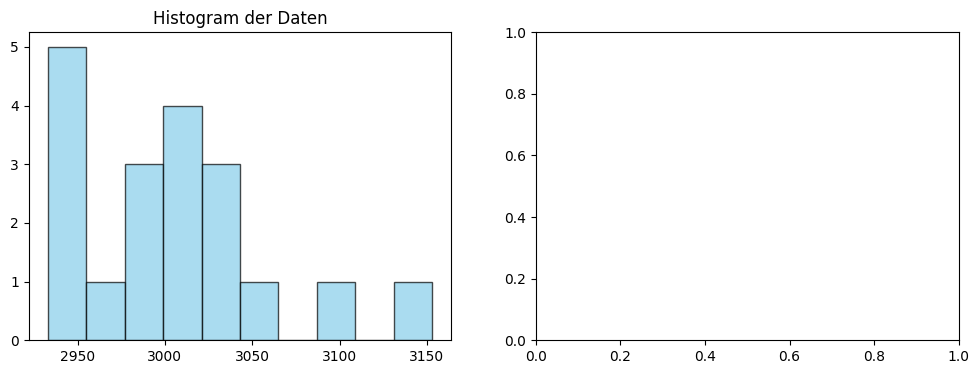

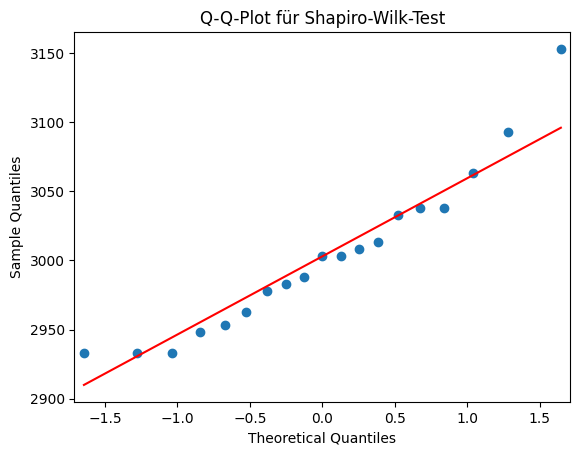

Anderson-Darling-Statistik: 0.375681502935322
Kritische Werte für Anderson-Darling-Test: [0.505 0.575 0.69  0.804 0.957]
Anderson-Darling-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.
Shapiro-Wilk-Statistik: 0.9276606440544128
P-Wert für Shapiro-Wilk-Test: 0.15680813789367676
Shapiro-Wilk-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.


In [13]:
import numpy as np
from scipy.stats import anderson, shapiro
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Extrahiere die beobachteten Werte
observed_data = list(feature_counts.values())

# Führe den Anderson-Darling-Test durch
result_anderson = anderson(observed_data)
alpha = 0.05  # Signifikanzniveau

# Führe den Shapiro-Wilk-Test durch
statistic_shapiro, p_value_shapiro = shapiro(observed_data)

# Histogramm
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(observed_data, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram der Daten')

# Q-Q-Plot für den Shapiro-Wilk-Test
plt.subplot(1, 2, 2)
sm.qqplot(np.array(observed_data), line='s', color='lightcoral')
plt.title('Q-Q-Plot für Shapiro-Wilk-Test')

plt.show()

# Zeige die Testergebnisse und Interpretation
print(f"Anderson-Darling-Statistik: {result_anderson.statistic}")
print(f"Kritische Werte für Anderson-Darling-Test: {result_anderson.critical_values}")
if result_anderson.statistic > result_anderson.critical_values[2]:
    print("Anderson-Darling-Test: Die Daten weichen signifikant von einer Normalverteilung ab.")
else:
    print("Anderson-Darling-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.")

print(f"Shapiro-Wilk-Statistik: {statistic_shapiro}")
print(f"P-Wert für Shapiro-Wilk-Test: {p_value_shapiro}")
if p_value_shapiro < alpha:
    print("Shapiro-Wilk-Test: Die Daten weichen signifikant von einer Normalverteilung ab.")
else:
    print("Shapiro-Wilk-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.")

In [14]:
df.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features
0,2023-11-12T13:00:24,DecisionTree_19_features_reduced_by_0_percent0,b089c878-b567-4b5e-ae70-03abeaade72a,0.299119,1.504002e-06,0.000005,42.5,0.0,4.754379,3.483172e-06,...,53.2157,12.678345,machine,N,1.0,19,0,"[housing, pdays, contact, cons.conf.idx, nr.em...",17,1
1,2023-11-12T13:00:26,DecisionTree_19_features_reduced_by_20_percent0,770b3004-eee9-4bd5-9821-dccecd4d942d,0.171267,8.497686e-07,0.000005,42.5,0.0,4.754379,1.969609e-06,...,53.2157,12.678345,machine,N,1.0,19,20,"[housing, pdays, contact, cons.conf.idx, nr.em...",17,1
2,2023-11-12T13:00:28,DecisionTree_19_features_reduced_by_40_percent0,2b72544f-d62a-4ab4-a940-c8e159941119,0.132989,6.234077e-07,0.000005,42.5,0.0,4.754379,1.444711e-06,...,53.2157,12.678345,machine,N,1.0,19,40,"[housing, pdays, contact, cons.conf.idx, nr.em...",17,1
3,2023-11-12T13:00:30,DecisionTree_19_features_reduced_by_60_percent0,20cb3715-3a20-479f-9b16-aa9e51ecb21f,0.093119,4.414532e-07,0.000005,42.5,0.0,4.754379,1.024619e-06,...,53.2157,12.678345,machine,N,1.0,19,60,"[housing, pdays, contact, cons.conf.idx, nr.em...",17,1
4,2023-11-12T13:00:31,DecisionTree_19_features_reduced_by_80_percent0,a27f9f39-c84b-4842-a897-92226f7946d9,0.047154,2.168466e-07,0.000005,42.5,0.0,4.754379,5.048775e-07,...,53.2157,12.678345,machine,N,1.0,19,80,"[housing, pdays, contact, cons.conf.idx, nr.em...",17,1


# Korrelationen

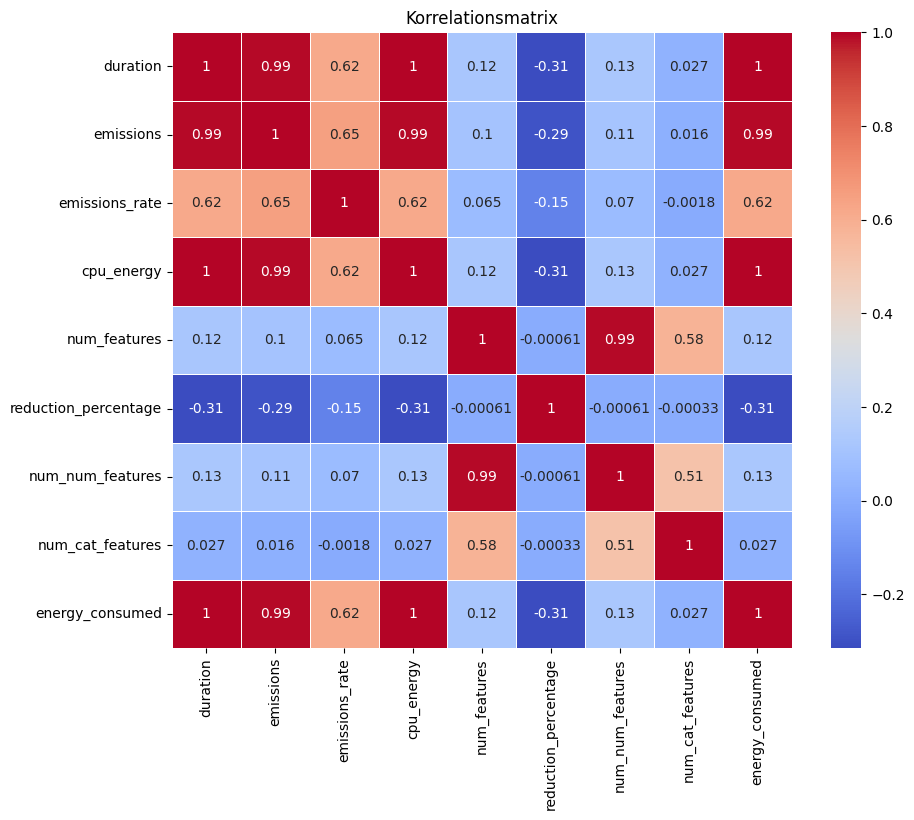

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Spalten definieren, welche behalten werden sollen
selected_columns = ['duration', 'emissions', 'emissions_rate', 'cpu_energy', 'num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features', 'energy_consumed']

# Erstelle die Korrelationsmatrix nur für die ausgewählten Spalten
correlation_matrix = df[selected_columns].corr()

# Erstelle eine Heatmap der Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korrelationsmatrix')
plt.show()